<a href="https://colab.research.google.com/github/xchuckz/collab_projects/blob/main/F1(Race_Time_Prediction_Final).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from ipywidgets import widgets, interact

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

**Data loading**

In [ ]:
results = pd.read_csv('results.csv')
races = pd.read_csv('races.csv')
drivers = pd.read_csv('drivers.csv')
constructors = pd.read_csv('constructors.csv')
circuits = pd.read_csv('circuits.csv')

print("Files loaded.")
print(f"Results rows: {len(results)} | Drivers rows: {len(drivers)} | Constructors rows: {len(constructors)}")

Files loaded.
Results rows: 26759 | Drivers rows: 861 | Constructors rows: 212


**Data Cleaning & Feature Creation**

In [ ]:
# Merge race-level info (year, circuitId)
data = results.merge(races[['raceId','year','circuitId']], on='raceId', how='left')

# milliseconds -> numeric and compute race_time_min
data['milliseconds'] = pd.to_numeric(data.get('milliseconds', pd.Series()), errors='coerce')
data = data.dropna(subset=['milliseconds'])
data['race_time_min'] = data['milliseconds'] / 60000.0

# Remove extreme outliers (simple bounds)
data = data[(data['race_time_min'] > 60) & (data['race_time_min'] < 150)]

# historical averages for driver and constructor (simple features)
driver_avg = data.groupby('driverId')['race_time_min'].mean().rename('driver_avg_time')
team_avg = data.groupby('constructorId')['race_time_min'].mean().rename('team_avg_time')
data = data.merge(driver_avg, on='driverId', how='left')
data = data.merge(team_avg, on='constructorId', how='left')
data = data[['grid', 'year', 'circuitId', 'constructorId', 'driverId', 'driver_avg_time', 'team_avg_time', 'race_time_min']].copy()
data = data.dropna()
# drop rows with any missing values in these
print("Prepared dataset shape:", data.shape)
data.head()


Prepared dataset shape: (7193, 8)


,grid,year,circuitId,constructorId,driverId,driver_avg_time,team_avg_time,race_time_min
0,1,2008,1,1,1,96.402580,96.842574,94.843600
1,5,2008,1,2,2,93.432846,94.119229,94.934900
2,7,2008,1,3,3,96.247700,96.255324,94.979650
3,11,2008,1,4,4,96.385117,93.609544,95.129950
4,3,2008,1,1,5,97.593886,96.842574,95.143833


**Encode categorical ids**

In [ ]:
# We convert each id column to a categorical and keep a mapping raw_id -> code
def create_code_map(series):
    cat = series.astype('category')
    mapping = {val: code for code, val in enumerate(cat.cat.categories)}
    codes = cat.cat.codes
    return codes, mapping

# Apply mapping & keep maps
data['circuit_code'], circuit_map = create_code_map(data['circuitId'])
data['constructor_code'], constructor_map = create_code_map(data['constructorId'])
data['driver_code'], driver_map = create_code_map(data['driverId'])

# For convenience, create reverse maps if needed
# (raw id -> code), we already have mapping above
# Also create name -> raw id maps for using human-readable names in widget
driver_name_to_raw = dict(zip(drivers['surname'], drivers['driverId']))
constructor_name_to_raw = dict(zip(constructors['name'], constructors['constructorId']))
circuit_name_to_raw = dict(zip(circuits['name'], circuits['circuitId']))

# Replace columns used for modeling with the numeric codes
data_for_model = data.rename(columns={
    'circuit_code': 'circuit',
    'constructor_code': 'constructor',
    'driver_code': 'driver'
})[['grid', 'year', 'circuit', 'constructor', 'driver', 'driver_avg_time', 'team_avg_time', 'race_time_min']].copy()

# Save feature list and target for clarity
features = ['grid', 'year', 'circuit', 'constructor', 'driver', 'driver_avg_time', 'team_avg_time']
target = 'race_time_min'
data_for_model.head()


,grid,year,circuit,constructor,driver,driver_avg_time,team_avg_time,race_time_min
0,1,2008,0,0,0,96.402580,96.842574,94.843600
1,5,2008,0,1,1,93.432846,94.119229,94.934900
2,7,2008,0,2,2,96.247700,96.255324,94.979650
3,11,2008,0,3,3,96.385117,93.609544,95.129950
4,3,2008,0,0,4,97.593886,96.842574,95.143833


**VISUALIZATIONS**

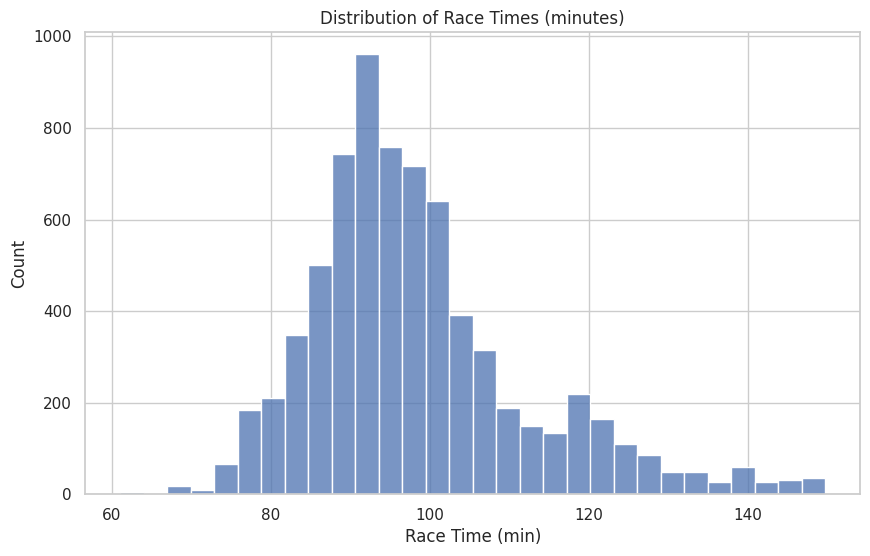

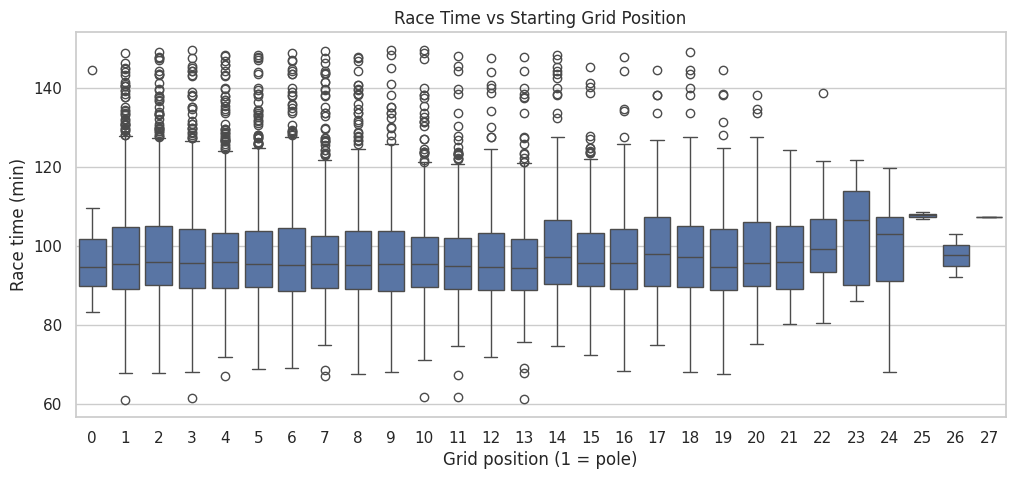

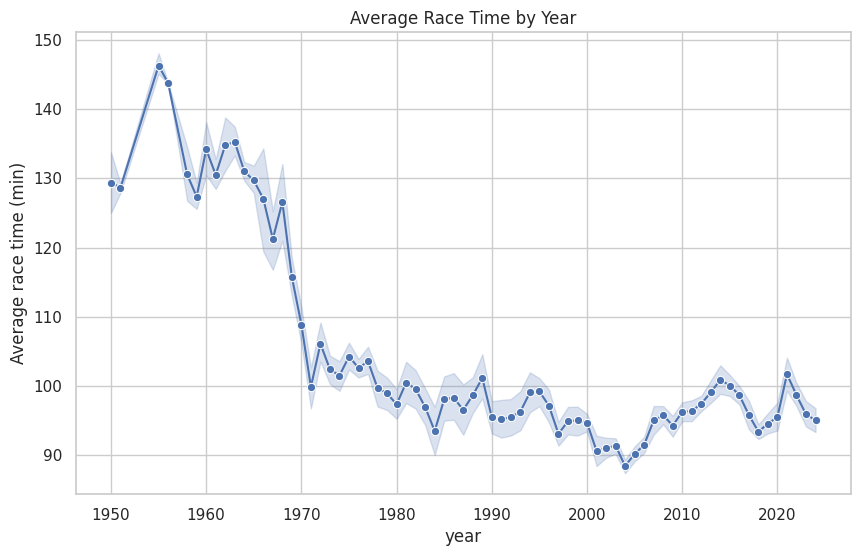

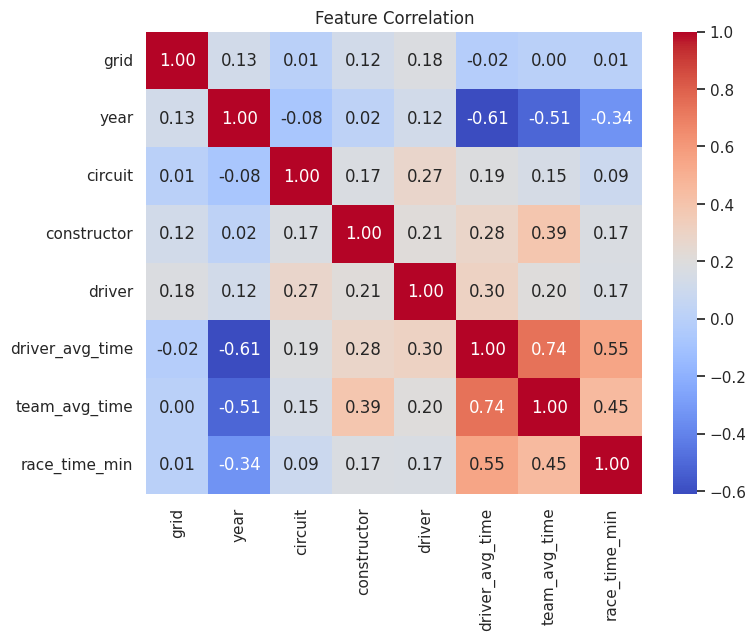

/tmp/ipython-input-1543715575.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_teams.values, y=[str(i) for i in top_teams.index], palette='Greens')


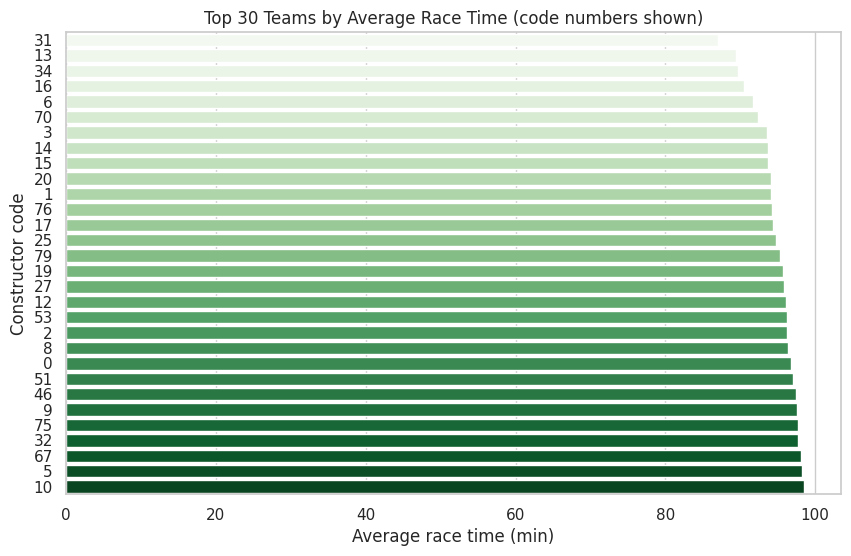

In [ ]:
# 1) Distribution of race times
plt.figure()
sns.histplot(data_for_model['race_time_min'], bins=30)
plt.title("Distribution of Race Times (minutes)")
plt.xlabel("Race Time (min)")
plt.show()

# 2) Boxplot: Race time by grid (starting position)
plt.figure(figsize=(12,5))
sns.boxplot(x='grid', y='race_time_min', data=data_for_model.sort_values('grid'))
plt.title("Race Time vs Starting Grid Position")
plt.xlabel("Grid position (1 = pole)")
plt.ylabel("Race time (min)")
plt.show()

# 3) Average race time by year (trend)
plt.figure()
sns.lineplot(x='year', y='race_time_min', data=data_for_model, estimator='mean', marker='o')
plt.title("Average Race Time by Year")
plt.ylabel("Average race time (min)")
plt.show()

# 4) Correlation heatmap (numeric)
plt.figure(figsize=(8,6))
sns.heatmap(data_for_model.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

# 5) Top 30 teams by average race time (lower = faster)
top_teams = data_for_model.groupby('constructor')['race_time_min'].mean().sort_values().head(30)
plt.figure()
sns.barplot(x=top_teams.values, y=[str(i) for i in top_teams.index], palette='Greens')
plt.title("Top 30 Teams by Average Race Time (code numbers shown)")
plt.xlabel("Average race time (min)")
plt.ylabel("Constructor code")
plt.show()


**Test Train split & Scaling**

In [ ]:
#Train/test split
X = data_for_model[features].copy()
y = data_for_model[target].copy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Scale numeric columns: grid, year, driver_avg_time, team_avg_time
numeric_cols = ['grid', 'year', 'driver_avg_time', 'team_avg_time']
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])
print("Train and test sets ready. X_train shape:", X_train.shape)

Train and test sets ready. X_train shape: (5394, 7)


**Modeling**

In [ ]:
# Model 1: Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)
print("Linear Regression results:")
print(f" MAE : {mae_lr:.2f} min")
print(f" RMSE: {rmse_lr:.2f} min")
print(f" R2  : {r2_lr:.3f}")

#Model 2: Random Forest
rf = RandomForestRegressor(n_estimators=150, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
print("Random Forest results:")
print(f" MAE : {mae_rf:.2f} min")
print(f" RMSE: {rmse_rf:.2f} min")
print(f" R2  : {r2_rf:.3f}")

# Feature importances (simple)
feat_imp = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)
print("\nTop features by importance:")
print(feat_imp.head(10))


Linear Regression results:
 MAE : 8.32 min
 RMSE: 11.34 min
 R2  : 0.313
Random Forest results:
 MAE : 2.38 min
 RMSE: 4.29 min
 R2  : 0.902

Top features by importance:
           feature  importance
1             year    0.480535
2          circuit    0.406603
5  driver_avg_time    0.051367
0             grid    0.024209
4           driver    0.015034
6    team_avg_time    0.012115
3      constructor    0.010137


 **Evaluation & Interpretation**

               Model       MAE       RMSE        R2
0  Linear Regression  8.322489  11.342284  0.312706
1      Random Forest  2.380074   4.292989  0.901540


/tmp/ipython-input-3509656131.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='R2', data=comparison, palette='pastel')


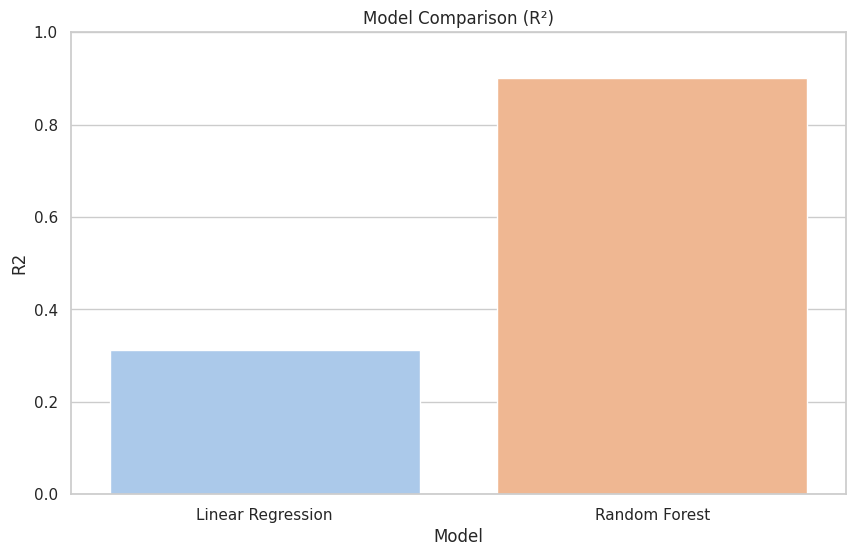

In [ ]:
#Simple comparison
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [mae_lr, mae_rf],
    'RMSE': [rmse_lr, rmse_rf],
    'R2': [r2_lr, r2_rf]
})
print(comparison)

#bar plot of R2
plt.figure()
sns.barplot(x='Model', y='R2', data=comparison, palette='pastel')
plt.title("Model Comparison (R²)")
plt.ylim(0, 1)
plt.show()

**Prediction function**

In [ ]:
# We need functions that convert human-readable names to the numeric codes we used for training.
# Build raw id -> code maps (these were created earlier as driver_map, constructor_map, circuit_map)
# driver_map / constructor_map / circuit_map map raw id -> code
# Ensure these exist (they were created when encoding)
# If not, rebuild simple maps from data columns:
try:
    _ = driver_map
except NameError:
    driver_map = {val: code for code, val in enumerate(data['driverId'].astype('category').cat.categories)}
    constructor_map = {val: code for code, val in enumerate(data['constructorId'].astype('category').cat.categories)}
    circuit_map = {val: code for code, val in enumerate(data['circuitId'].astype('category').cat.categories)}

# Build name -> raw id maps (for UI)
driver_name_to_raw = dict(zip(drivers['surname'], drivers['driverId']))
constructor_name_to_raw = dict(zip(constructors['name'], constructors['constructorId']))
circuit_name_to_raw = dict(zip(circuits['name'], circuits['circuitId']))

# Helper to map raw id -> code (fallback to nearest or mean)
def raw_to_code(mapping, raw_id):
    return mapping.get(raw_id, -1)  # -1 indicates unknown; we'll handle below

# Helper to get avg times safely
global_driver_avg = data_for_model['driver_avg_time'].mean()
global_team_avg = data_for_model['team_avg_time'].mean()

#Prediction function (choose 'lr' or 'rf')
def build_row_for_prediction(driver_name, team_name, circuit_name, grid, year):
    # Get raw ids from names
    try:
        driver_raw = driver_name_to_raw[driver_name]
    except KeyError:
        raise ValueError(f"Driver name '{driver_name}' not found. Try a different surname.")
    try:
        team_raw = constructor_name_to_raw[team_name]
    except KeyError:
        raise ValueError(f"Team name '{team_name}' not found.")
    try:
        circuit_raw = circuit_name_to_raw[circuit_name]
    except KeyError:
        raise ValueError(f"Circuit name '{circuit_name}' not found.")

    # Map raw ids to codes (if not present, use nearest fallback: mean code)
    driver_code = raw_to_code(driver_map, driver_raw)
    constructor_code = raw_to_code(constructor_map, team_raw)
    circuit_code = raw_to_code(circuit_map, circuit_raw)

    # If any code is -1 (unknown), replace with mode (simple fallback)
    if driver_code == -1:
        driver_code = int(np.round(np.mean(list(driver_map.values()))))
    if constructor_code == -1:
        constructor_code = int(np.round(np.mean(list(constructor_map.values()))))
    if circuit_code == -1:
        circuit_code = int(np.round(np.mean(list(circuit_map.values()))))

    # Get historical averages; if missing, use global averages
    try:
        d_avg = float(driver_avg.loc[driver_raw])
    except Exception:
        d_avg = global_driver_avg
    try:
        t_avg = float(team_avg.loc[team_raw])
    except Exception:
        t_avg = global_team_avg

    # Build row in same column order as training
    row = pd.DataFrame([{
        'grid': int(grid),
        'year': int(year),
        'circuit': int(circuit_code),
        'constructor': int(constructor_code),
        'driver': int(driver_code),
        'driver_avg_time': d_avg,
        'team_avg_time': t_avg
    }])

    # Scale numeric columns
    row[numeric_cols] = scaler.transform(row[numeric_cols])
    # Reorder columns to match training order
    row = row[features]
    return row

def predict_time(model_name, driver_name, team_name, circuit_name, grid=10, year=2025):
    row = build_row_for_prediction(driver_name, team_name, circuit_name, grid, year)
    if model_name == 'lr':
        pred = lr.predict(row)[0]
    elif model_name == 'rf':
        pred = rf.predict(row)[0]
    else:
        raise ValueError("model_name must be 'lr' or 'rf'")
    return pred

In [ ]:
driver_options = sorted(driver_name_to_raw.keys())
team_options = sorted(constructor_name_to_raw.keys())
circuit_options = sorted(circuit_name_to_raw.keys())
def widget_predict(model, driver, team, circuit, grid, year):
    try:
        pred = predict_time(model, driver, team, circuit, grid, year)
        print(f"\nModel: {'Linear Regression' if model=='lr' else 'Random Forest'}")
        print(f"Predicted race time for {driver} ({team}) at {circuit}: {pred:.2f} minutes")
    except Exception as e:
        print("Error:", e)

interact(
    widget_predict,
    model=widgets.RadioButtons(options=[('Linear Regression','lr'), ('Random Forest','rf')], description='Model:'),
    driver=widgets.Dropdown(options=driver_options, description='Driver'),
    team=widgets.Dropdown(options=team_options, description='Team'),
    circuit=widgets.Dropdown(options=circuit_options, description='Circuit'),
    grid=widgets.IntSlider(min=1, max=22, value=10, description='Grid'),
    year=widgets.IntText(value=2025, description='Year')
)

interactive(children=(RadioButtons(description='Model:', options=(('Linear Regression', 'lr'), ('Random Forest…

<function __main__.widget_predict(model, driver, team, circuit, grid, year)>